# Model Comparison: Logistic Regression vs. Random Forest

This notebook compares the three final tuned models from this project using models saved by `run_pipeline.py`. No model fitting happens here. This notebook loads the persisted models and re-derives comparison metrics/plots on the same held-out test set used throughout.

All three models were selected using the same methodology: 5-fold `StratifiedGroupKFold` (patient-grouped, shuffled) for cross-validation, with hyperparameters chosen by CV score and train/CV gap.

Some comparison was performed in the model notebooks, but this notebook comparisons models more explicitly and in one place. 

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

from src.data_loader import load_features
from src.preprocessing import clean_data, encode_categoricals
from src.split import patient_split, get_features_and_target
from src.evaluate import compute_metrics

# Rebuild the dataset (same deterministic pipeline as run_pipeline.py)
df = load_features()
df = clean_data(df)
train_df, test_df = patient_split(df)
X_train, y_train, ids_train = get_features_and_target(train_df)
X_test, y_test, ids_test = get_features_and_target(test_df)
X_train, X_test = encode_categoricals(X_train, X_test)

# Load saved models
final_lr = joblib.load('../../models/logistic_regression_final.joblib')
scaler = joblib.load('../../models/scaler.joblib')
final_rf = joblib.load('../../models/random_forest_final.joblib')
final_xgb = joblib.load('../../models/xgboost_final.joblib')

X_test_scaled = scaler.transform(X_test)

Loaded 101,766 rows, 54 columns.
Unique patients: 71,518

Columns with missing values:
race      2367
gender       3

Readmitted-within-30-days rate: 11.16%

  Dropped 2,423 rows with death/hospice discharge disposition.
  Dropped 3 rows with missing/invalid gender.
  Filled 2,320 missing race values with 'Unknown'.

Raw data: 101,766 encounters; Cleaned data: 99,340 encounters (2,426 dropped total).

Total encounters: 99,340 | Train: 79,462 (80.0%) | Test: 19,878 (20.0%)
Readmit rate - Full: 11.39% | Train: 11.36% | Test: 11.51%

Encoding 33 categorical columns: ['race', 'gender', 'admission_type', 'discharge_disposition', 'admission_source', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide_metformin', 'glipizide_metformin', 'glimepiride_p

In [2]:
# Evaluate the models on the test set
y_scores_lr = final_lr.predict_proba(X_test_scaled)[:, 1]
y_scores_rf = final_rf.predict_proba(X_test)[:, 1]
y_scores_xgb = final_xgb.predict_proba(X_test)[:, 1]

lr_metrics = compute_metrics(y_test, final_lr.predict_proba(X_test_scaled))
rf_metrics = compute_metrics(y_test, final_rf.predict_proba(X_test))
xgb_metrics = compute_metrics(y_test, final_xgb.predict_proba(X_test))

comparison_df = pd.DataFrame(
    [lr_metrics, rf_metrics, xgb_metrics],
    index=["Logistic Regression", "Random Forest", "XGBoost"]
)
comparison_df

,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold
Logistic Regression,0.665223,0.226813,0.673961,0.184024,0.533654,0.273675,0.5
Random Forest,0.670954,0.238158,0.643727,0.181335,0.596154,0.278084,0.5
XGBoost,0.675939,0.244291,0.653738,0.185058,0.590035,0.281749,0.5


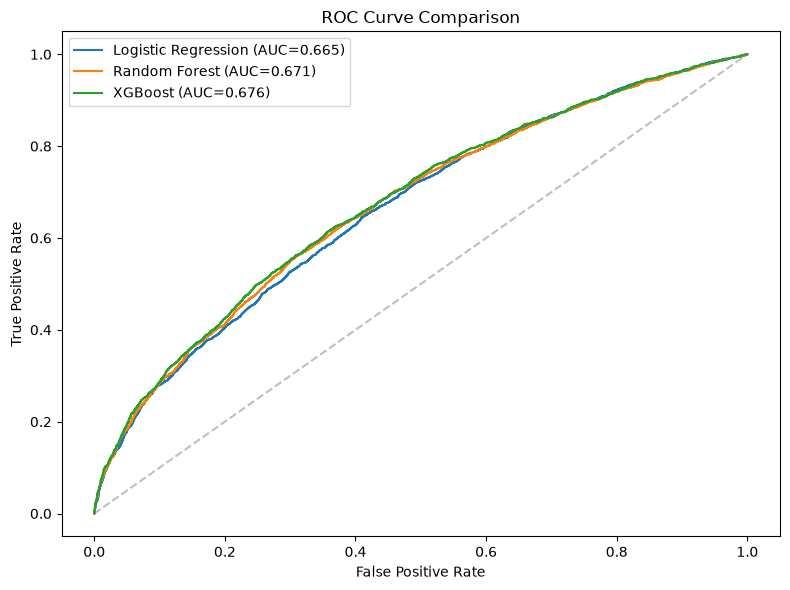

In [3]:
plt.figure(figsize=(8, 6))
for name, scores in [("Logistic Regression", y_scores_lr),
                      ("Random Forest", y_scores_rf),
                      ("XGBoost", y_scores_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, scores):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

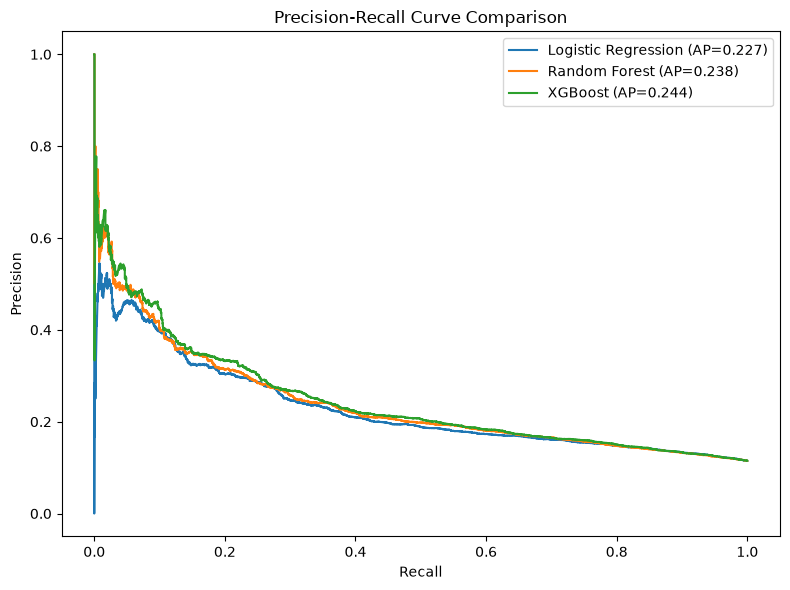

In [4]:
plt.figure(figsize=(8, 6))
for name, scores in [("Logistic Regression", y_scores_lr),
                      ("Random Forest", y_scores_rf),
                      ("XGBoost", y_scores_xgb)]:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, scores):.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Comparison 

When optimizing for threshold, both models obtained an optimal threshold close to the default threshold. At a matched threshold of 0.45, Random Forest achieves meaningfully higher recall than logistic regression (0.727 vs. 0.682) at essentially the same precision (0.161 vs. 0.163). This reinforces the modest edge already seen in PR-AUC for the Random Forest model but now at a lower, optimized threshold. 

In [5]:
from src.evaluate import threshold_sweep

sweep_lr = threshold_sweep(y_test, final_lr.predict_proba(X_test_scaled)).assign(model="Logistic Regression")
sweep_rf = threshold_sweep(y_test, final_rf.predict_proba(X_test)).assign(model="Random Forest")
sweep_xgb = threshold_sweep(y_test, final_xgb.predict_proba(X_test)).assign(model="XGBoost")

all_sweeps = pd.concat([sweep_lr, sweep_rf, sweep_xgb], ignore_index=True)
all_sweeps[all_sweeps["threshold"].isin([0.45, 0.5])].sort_values(["model", "threshold"])

,threshold,precision,recall,f1,accuracy,model
7,0.45,0.163180,0.681818,0.263336,0.560922,Logistic Regression
8,0.50,0.184024,0.533654,0.273675,0.673961,Logistic Regression
23,0.45,0.160552,0.726836,0.263008,0.531140,Random Forest
24,0.50,0.181335,0.596154,0.278084,0.643727,Random Forest
39,0.45,0.162842,0.713287,0.265150,0.544924,XGBoost
40,0.50,0.185058,0.590035,0.281749,0.653738,XGBoost


In [6]:
top_rf = pd.Series(final_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
top_xgb = pd.Series(final_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

print("Random Forest — top 10:")
print(top_rf)
print("\nXGBoost — top 10:")
print(top_xgb)

# Logistic regression: sign indicates direction (positive = pushes toward readmit)
coef_lr = pd.Series(final_lr.coef_[0], index=X_train.columns)
print("\nLogistic Regression — top 10 positive coefficients (readmit risk ↑):")
print(coef_lr.sort_values(ascending=False).head(10))

Random Forest — top 10:
number_inpatient                                                                                           0.370512
discharge_disposition_Discharged to home                                                                   0.101058
discharge_disposition_Discharged/transferred to another rehab fac including rehab units of a hospital .    0.061933
number_diagnoses                                                                                           0.039675
number_emergency                                                                                           0.037127
num_lab_procedures                                                                                         0.037016
time_in_hospital                                                                                           0.036098
num_medications                                                                                            0.033320
age_numeric                                     

### Feature Agreement Across Models

All three models agree `number_inpatient` (prior inpatient visits) is the single strongest predictor of 30-day readmission. For random forest and logistic regression, there a significant gap between `number_inpatient` and the 2nd most important feature. While XGBoost still has `num_inpatient` as its top feature, the importance is spread more evenly across features. This is also consistent with the EDA's finding. 

`discharge_disposition` categories (particularly "another rehab facility" and "SNF") and `number_diagnoses`/`number_emergency` also rank highly across all three (all within the top 10), reinforcing that where a patient is discharged to and their overall disease/visit burden are the dominant risk signals in this dataset, independent of model choice.

## Final Thoughts

XGBoost is the strongest performer across threshold-independent metrics: test PR-AUC (0.244 vs. Random Forest's 0.238 and Logistic Regression's 0.227) and test ROC-AUC (0.676 vs. 0.671 vs. 0.665). The PR curve comparison shows this advantage holds across most of the recall range, not just at one threshold.

Recall, our secondary metric, is where Random Forest slightly outperforms XGBoost. For instance, at a matched threshold of 0.45 (where recall is optimized without significantly sacrificing precision), Random Forest edges ahead (0.727 vs. XGBoost's 0.713) at slightly lower precision (0.161 vs. 0.163) and a marginally lower F1 (0.263 vs. 0.265). The two tree-based models are close enough here that the choice between them depends on whether recall or balanced performance matters more for the use case.

All three models were tuned and selected using almost identical methodology. The same dataset and feature matrix shuffled by patient grouping with hyperparameters chosen by CV score and CV score gap, so this comparison reflects genuine differences in how well each model class fits the data, not differences in how carefully each was tuned. With the only method difference in using `GridSearchCV` vs. `RandomSearchCV`. 

**Recommendation:** XGBoost is the strongest overall performer and the primary recommendation. If the deployment priority is strictly maximizing recall, i.e. flagging as many true early readmissions as possible, even at a further cost to precision, then Random Forest at threshold≈0.45 is a close, defensible alternative.